# Fraud Detection Pipeline

Three complementary approaches to detecting fraudulent clothing listings:
1. **Metadata heuristics** — rule-based contradiction detection
2. **Anomaly detection on learned embeddings** — IsolationForest on features from the trained model
3. **CLIP zero-shot comparison** — vision-language model compares image content to stated condition

The key insight: with only 95 fraud candidates in 32K items (0.3%), standard classification fails. These approaches sidestep the class imbalance problem.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)

CSV_PATH = Path("../data/cleaned_metadata_v2.csv")
CHECKPOINT_DIR = Path("../checkpoints_v2")
FIGURES_DIR = Path("../report/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)
train_df = df[df["split"] == "train"]
test_df  = df[df["split"] == "test"]

print(f"Total: {len(df):,}  |  Train: {len(train_df):,}  |  Test: {len(test_df):,}")
print(f"Fraud candidates: {df['is_fraud_candidate'].sum()} "
      f"(train={train_df['is_fraud_candidate'].sum()}, test={test_df['is_fraud_candidate'].sum()})")

Total: 31,936  |  Train: 25,548  |  Test: 6,388
Fraud candidates: 95 (train=72, test=23)


## Approach 1: Metadata Heuristic Baseline

Flag items with contradictory metadata: high stated condition but major defects detected. This catches obvious fraud with zero ML.

In [2]:
def heuristic_fraud_flags(df):
    """
    Flag items with contradictions between stated condition and defect labels.
    
    Rules:
    1. condition >= 4 AND (stains == 2 OR holes == 2)  [original fraud flag]
    2. condition >= 4 AND pilling <= 2                   [claims good but heavy pilling]
    3. condition == 5 AND (stains >= 1 OR holes >= 1)    [claims perfect but has defects]
    """
    rule1 = (df["condition"] >= 4) & ((df["stains"] == 2) | (df["holes"] == 2))
    rule2 = (df["condition"] >= 4) & (df["pilling"] <= 2)
    rule3 = (df["condition"] == 5) & ((df["stains"] >= 1) | (df["holes"] >= 1))
    
    combined = rule1 | rule2 | rule3
    return combined, {"rule1_condition+defect": rule1.sum(),
                      "rule2_condition+pilling": rule2.sum(),
                      "rule3_perfect+any_defect": rule3.sum(),
                      "combined": combined.sum()}

# Apply to test set
test_flags, rule_counts = heuristic_fraud_flags(test_df)
print("Heuristic rule hits (test set):")
for rule, count in rule_counts.items():
    print(f"  {rule}: {count}")

# Evaluate against ground truth
y_true = test_df["is_fraud_candidate"].values.astype(int)
y_pred_heuristic = test_flags.values.astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred_heuristic, average="binary", zero_division=0)
print(f"\nHeuristic Fraud Detection (test set):")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  Flagged:   {y_pred_heuristic.sum()} items")
print(f"  True fraud in test: {y_true.sum()}")

Heuristic rule hits (test set):
  rule1_condition+defect: 23
  rule2_condition+pilling: 54
  rule3_perfect+any_defect: 33
  combined: 102

Heuristic Fraud Detection (test set):
  Precision: 0.2255
  Recall:    1.0000
  F1:        0.3680
  Flagged:   102 items
  True fraud in test: 23


## Approach 2: Anomaly Detection on Learned Embeddings

Extract the 2816-d feature vectors from the trained multi-task model, reduce dimensionality with PCA, then use IsolationForest to flag outliers as potential fraud.

In [3]:
import timm
from tqdm import tqdm

# Rebuild the model architecture (must match model_v2.ipynb)
class ClothingMultiTaskModel(nn.Module):
    def __init__(self, backbone_name="efficientnet_b2", pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            in_chans=3, num_classes=0, global_pool="avg",
        )
        feat_dim = self.backbone.num_features
        combined_dim = feat_dim * 2

        self.condition_head = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(combined_dim, 256),
            nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(256, 5),
        )
        self.stains_head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(combined_dim, 64),
            nn.ReLU(inplace=True), nn.Linear(64, 3),
        )
        self.holes_head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(combined_dim, 64),
            nn.ReLU(inplace=True), nn.Linear(64, 3),
        )
        self.pilling_head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(combined_dim, 64),
            nn.ReLU(inplace=True), nn.Linear(64, 5),
        )

    def forward(self, front, back):
        f_front = self.backbone(front)
        f_back  = self.backbone(back)
        combined = torch.cat([f_front, f_back], dim=1)
        return {"condition": self.condition_head(combined),
                "stains": self.stains_head(combined),
                "holes": self.holes_head(combined),
                "pilling": self.pilling_head(combined)}

    def get_embeddings(self, front, back):
        f_front = self.backbone(front)
        f_back  = self.backbone(back)
        return torch.cat([f_front, f_back], dim=1)


# Load trained weights
model = ClothingMultiTaskModel(pretrained=False).to(DEVICE)
weights_path = CHECKPOINT_DIR / "best_model_v2.pt"
if not weights_path.exists():
    # Fallback: extract from checkpoint
    ckpt = torch.load(CHECKPOINT_DIR / "best_checkpoint.pt", map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=False))
model.eval()
print(f"Loaded model from {CHECKPOINT_DIR}")

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model from ../checkpoints_v2


In [4]:
IMG_SIZE = 260

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class SimpleClothingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        front = Image.open(row["front_path"]).convert("RGB")
        back  = Image.open(row["back_path"]).convert("RGB")
        if self.transform:
            front = self.transform(front)
            back  = self.transform(back)
        return front, back


@torch.no_grad()
def extract_embeddings(model, dataframe, batch_size=32):
    """Extract 2816-d embeddings for all items in dataframe."""
    dataset = SimpleClothingDataset(dataframe, transform=eval_transforms)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_embeds = []
    for fronts, backs in tqdm(loader, desc="Extracting embeddings"):
        fronts = fronts.to(DEVICE)
        backs  = backs.to(DEVICE)
        embeds = model.get_embeddings(fronts, backs)
        all_embeds.append(embeds.cpu().numpy())
        if DEVICE.type == "mps":
            torch.mps.synchronize()
    
    return np.concatenate(all_embeds, axis=0)


print("Extracting train embeddings...")
train_embeddings = extract_embeddings(model, train_df)
print(f"Train embeddings: {train_embeddings.shape}")

print("Extracting test embeddings...")
test_embeddings = extract_embeddings(model, test_df)
print(f"Test embeddings: {test_embeddings.shape}")

Extracting train embeddings...


Extracting embeddings: 100%|██████████| 799/799 [07:18<00:00,  1.82it/s]


Train embeddings: (25548, 2816)
Extracting test embeddings...


Extracting embeddings: 100%|██████████| 200/200 [01:52<00:00,  1.78it/s]

Test embeddings: (6388, 2816)


In [5]:
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# PCA to reduce 2816-d → 100-d (IsolationForest works better in lower dimensions)
pca = PCA(n_components=100, random_state=42)
train_pca = pca.fit_transform(train_embeddings)
test_pca  = pca.transform(test_embeddings)

explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA: 2816-d → 100-d  (explained variance: {explained_var:.1%})")

# IsolationForest — contamination matches the fraud rate
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.005,  # slightly higher than true rate (0.3%) to improve recall
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(train_pca)

# Predict on test set (-1 = anomaly, 1 = normal)
test_iso_pred = iso_forest.predict(test_pca)
test_iso_scores = iso_forest.decision_function(test_pca)

y_pred_iso = (test_iso_pred == -1).astype(int)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred_iso, average="binary", zero_division=0)

print(f"\nIsolationForest Fraud Detection (test set):")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  Flagged:   {y_pred_iso.sum()} items")
print(f"  True fraud caught: {(y_pred_iso & y_true).sum()} / {y_true.sum()}")

PCA: 2816-d → 100-d  (explained variance: 60.7%)

IsolationForest Fraud Detection (test set):
  Precision: 0.0000
  Recall:    0.0000
  F1:        0.0000
  Flagged:   19 items
  True fraud caught: 0 / 23


### t-SNE Visualization of Embeddings

Visualize the learned feature space. Fraud candidates should ideally cluster in unusual regions.

Running t-SNE on test embeddings (this may take a minute)...


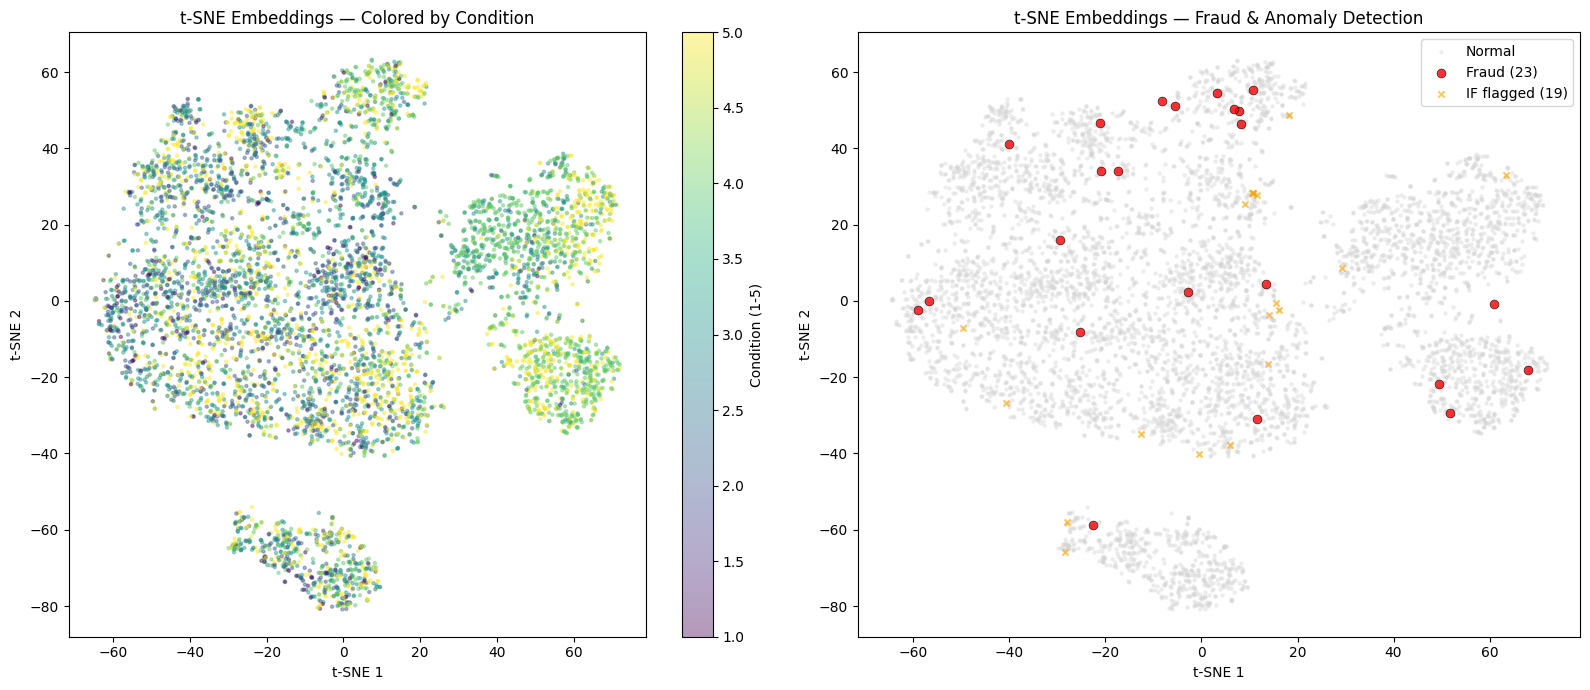

Saved to ../report/figures/fraud_tsne.png


In [6]:
from sklearn.manifold import TSNE

# Use PCA-reduced embeddings for t-SNE (faster)
print("Running t-SNE on test embeddings (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
test_tsne = tsne.fit_transform(test_pca)

test_fraud = test_df.reset_index(drop=True)["is_fraud_candidate"].values
test_condition = test_df.reset_index(drop=True)["condition"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Color by condition
scatter1 = axes[0].scatter(test_tsne[:, 0], test_tsne[:, 1],
                           c=test_condition, cmap="viridis", s=5, alpha=0.4)
plt.colorbar(scatter1, ax=axes[0], label="Condition (1-5)")
axes[0].set_title("t-SNE Embeddings — Colored by Condition", fontsize=12)
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")

# Highlight fraud candidates
normal_mask = ~test_fraud.astype(bool)
fraud_mask  = test_fraud.astype(bool)
axes[1].scatter(test_tsne[normal_mask, 0], test_tsne[normal_mask, 1],
                c="lightgrey", s=5, alpha=0.3, label="Normal")
axes[1].scatter(test_tsne[fraud_mask, 0], test_tsne[fraud_mask, 1],
                c="red", s=40, alpha=0.8, edgecolors="black", linewidths=0.5,
                label=f"Fraud ({fraud_mask.sum()})", zorder=5)
# Also show IsolationForest flags
iso_mask = y_pred_iso.astype(bool)
axes[1].scatter(test_tsne[iso_mask & ~fraud_mask, 0], test_tsne[iso_mask & ~fraud_mask, 1],
                c="orange", s=20, alpha=0.6, marker="x",
                label=f"IF flagged ({iso_mask.sum()})", zorder=4)
axes[1].set_title("t-SNE Embeddings — Fraud & Anomaly Detection", fontsize=12)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {FIGURES_DIR / 'fraud_tsne.png'}")

## Approach 3: CLIP Zero-Shot Condition Assessment

Use a pretrained vision-language model to independently assess clothing condition from images, without any task-specific training. Compare CLIP's assessment to the seller's stated condition — large discrepancies signal potential fraud.

In [7]:
import open_clip

# Free the previous model's GPU memory
del model
if DEVICE.type == "mps":
    torch.mps.empty_cache()

# Load CLIP model
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer("ViT-B-32")

print(f"CLIP ViT-B/32 loaded ({sum(p.numel() for p in clip_model.parameters()):,} params)")

# Define condition prompts
condition_prompts = [
    "a photo of clothing in very poor condition with major damage",
    "a photo of clothing in fair condition with some wear",
    "a photo of clothing in good condition with minor wear",
    "a photo of clothing in very good condition with minimal wear",
    "a photo of clothing in excellent pristine condition like new",
]

# Encode text prompts
with torch.no_grad():
    text_tokens = tokenizer(condition_prompts).to(DEVICE)
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"Text features: {text_features.shape}")
for i, prompt in enumerate(condition_prompts):
    print(f"  Class {i}: {prompt}")

CLIP ViT-B/32 loaded (151,277,313 params)
Text features: torch.Size([5, 512])
  Class 0: a photo of clothing in very poor condition with major damage
  Class 1: a photo of clothing in fair condition with some wear
  Class 2: a photo of clothing in good condition with minor wear
  Class 3: a photo of clothing in very good condition with minimal wear
  Class 4: a photo of clothing in excellent pristine condition like new


In [8]:
@torch.no_grad()
def clip_predict_condition(clip_model, text_features, image_paths, batch_size=64):
    """Predict condition for a list of image paths using CLIP zero-shot."""
    all_preds = []
    all_scores = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc="CLIP inference"):
        batch_paths = image_paths[i:i+batch_size]
        images = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB")
            img = clip_preprocess(img)
            images.append(img)
        
        images = torch.stack(images).to(DEVICE)
        image_features = clip_model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        
        # Cosine similarity → predicted condition
        similarity = (image_features @ text_features.T) * 100  # scale for softmax
        probs = similarity.softmax(dim=-1)
        preds = probs.argmax(dim=-1)
        
        all_preds.append(preds.cpu().numpy())
        all_scores.append(probs.cpu().numpy())
        
        if DEVICE.type == "mps":
            torch.mps.synchronize()
    
    return np.concatenate(all_preds), np.concatenate(all_scores)


# Run CLIP on front images of test set
test_front_paths = test_df["front_path"].values.tolist()
clip_preds, clip_scores = clip_predict_condition(clip_model, text_features, test_front_paths)

# Ground truth (0-indexed)
test_true = test_df.reset_index(drop=True)["condition"].values - 1

clip_acc = (clip_preds == test_true).mean()
clip_mae = np.abs(clip_preds - test_true).mean()
clip_one_off = (np.abs(clip_preds - test_true) <= 1).mean()

print(f"\nCLIP Zero-Shot Condition Assessment (test set):")
print(f"  Accuracy:     {clip_acc:.4f}")
print(f"  MAE:          {clip_mae:.3f}")
print(f"  1-off Acc:    {clip_one_off:.4f}")

CLIP inference: 100%|██████████| 100/100 [01:09<00:00,  1.43it/s]


CLIP Zero-Shot Condition Assessment (test set):
  Accuracy:     0.2924
  MAE:          0.983
  1-off Acc:    0.7466


CLIP Discrepancy Fraud Detection (threshold: |diff| >= 2):
  Precision: 0.0025
  Recall:    0.1739
  F1:        0.0049
  Flagged:   1619 items


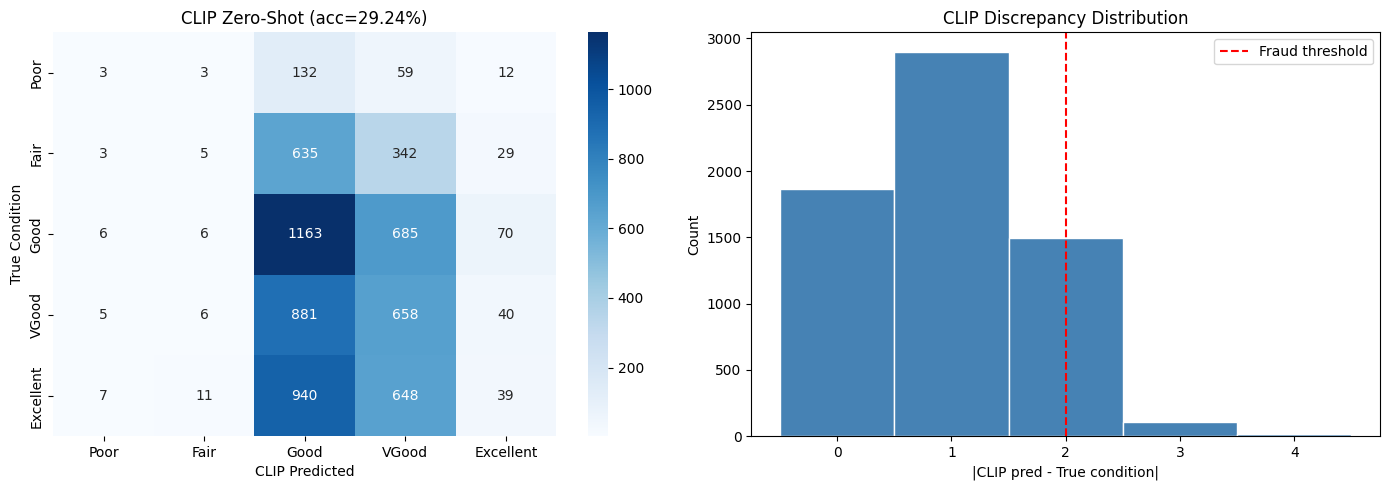

In [9]:
# CLIP-based fraud signal: large discrepancy between CLIP prediction and stated condition
clip_discrepancy = np.abs(clip_preds - test_true)

# Flag items where CLIP disagrees by 2+ grades
y_pred_clip = (clip_discrepancy >= 2).astype(int)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred_clip, average="binary", zero_division=0)

print(f"CLIP Discrepancy Fraud Detection (threshold: |diff| >= 2):")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  Flagged:   {y_pred_clip.sum()} items")

# Visualize CLIP prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CLIP predictions vs ground truth
from sklearn.metrics import confusion_matrix as cm_func
cm_clip = cm_func(test_true, clip_preds)
cond_labels = ["Poor", "Fair", "Good", "VGood", "Excellent"]
sns.heatmap(cm_clip, annot=True, fmt="d", cmap="Blues",
            xticklabels=cond_labels, yticklabels=cond_labels, ax=axes[0])
axes[0].set_xlabel("CLIP Predicted"); axes[0].set_ylabel("True Condition")
axes[0].set_title(f"CLIP Zero-Shot (acc={clip_acc:.2%})")

# Discrepancy distribution
axes[1].hist(clip_discrepancy, bins=range(6), color="steelblue", edgecolor="white", align="left")
axes[1].axvline(x=2, color="red", linestyle="--", label="Fraud threshold")
axes[1].set_title("CLIP Discrepancy Distribution")
axes[1].set_xlabel("|CLIP pred - True condition|")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "clip_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Combined Ensemble & Summary

Combine all three fraud signals with a simple majority vote. Any item flagged by 2+ methods is marked as suspicious.

In [10]:
# Ensemble: majority vote (flagged by 2+ methods)
vote_sum = y_pred_heuristic + y_pred_iso + y_pred_clip
y_pred_ensemble = (vote_sum >= 2).astype(int)

# Also try union (flagged by any method)
y_pred_union = ((y_pred_heuristic | y_pred_iso | y_pred_clip)).astype(int)

results = []
for name, y_pred in [
    ("Heuristic Rules", y_pred_heuristic),
    ("IsolationForest", y_pred_iso),
    ("CLIP Discrepancy", y_pred_clip),
    ("Ensemble (2/3 vote)", y_pred_ensemble),
    ("Union (any method)", y_pred_union),
]:
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    results.append({
        "Method": name,
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1": f"{f1:.4f}",
        "Flagged": int(y_pred.sum()),
        "True Fraud Caught": int((y_pred & y_true).sum()),
    })

results_df = pd.DataFrame(results)
print("=" * 80)
print("  FRAUD DETECTION COMPARISON (test set)")
print("=" * 80)
print(results_df.to_string(index=False))
print(f"\nTotal true fraud candidates in test: {y_true.sum()}")
print("=" * 80)

# Save results
results_df.to_csv(FIGURES_DIR / "fraud_results.csv", index=False)
print(f"\nSaved to {FIGURES_DIR / 'fraud_results.csv'}")

  FRAUD DETECTION COMPARISON (test set)
             Method Precision Recall     F1  Flagged  True Fraud Caught
    Heuristic Rules    0.2255 1.0000 0.3680      102                 23
    IsolationForest    0.0000 0.0000 0.0000       19                  0
   CLIP Discrepancy    0.0025 0.1739 0.0049     1619                  4
Ensemble (2/3 vote)    0.1481 0.1739 0.1600       27                  4
 Union (any method)    0.0134 1.0000 0.0265     1713                 23

Total true fraud candidates in test: 23

Saved to ../report/figures/fraud_results.csv
